In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Cargar el dataset

In [2]:
url = "https://raw.githubusercontent.com/erickedu85/dataset/refs/heads/master/adult/adult.data"

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(url, names=column_names)


In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Columnas numéricas:")
print(numeric_columns)

print("\nColumnas categóricas:")
print(categorical_columns)

missing_values = df.isna().sum().rename("valores_nan").to_frame()
display(missing_values)

Columnas numéricas:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Columnas categóricas:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


,valores_nan
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [6]:
for column in categorical_columns:
    print(f"\n{column}:")
    display(df[column].value_counts(dropna=False).rename("frecuencia").to_frame())


workclass:


,frecuencia
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7



education:


,frecuencia
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646



marital-status:


...

,frecuencia
sex,
Male,21790
Female,10771



native-country:


,frecuencia
native-country,
United-States,29170
Mexico,643
?,583
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100



income:


,frecuencia
income,
<=50K,24720
>50K,7841


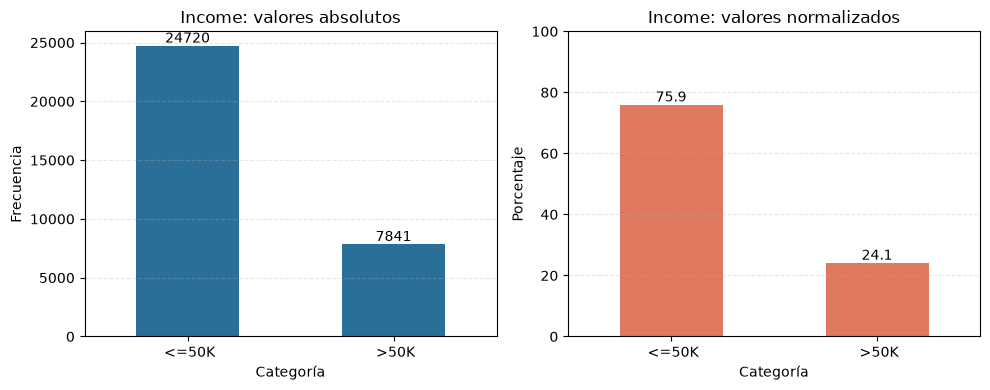

In [7]:


income_counts = df["income"].value_counts(dropna=False)
income_percentages = income_counts.div(income_counts.sum()).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
income_counts.plot(kind="bar", ax=axes[0], color="#2a6f97")
income_percentages.plot(kind="bar", ax=axes[1], color="#e07a5f")

axes[0].set_title("Income: valores absolutos")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Frecuencia")
axes[1].set_title("Income: valores normalizados")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Porcentaje")
axes[1].set_ylim(0, 100)

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="%.1f" if ax is axes[1] else "%.0f")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()

In [8]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
df[categorical_columns] = df[categorical_columns].apply(lambda values: values.str.strip())

In [9]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
df[categorical_columns] = df[categorical_columns].apply(
    lambda values: values.str.strip().replace("?", pd.NA)
)

In [10]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=column_names,
    na_position="last"
)
print(f"Filas involucradas en duplicados: {len(duplicate_rows)}")
display(duplicate_rows)

Filas involucradas en duplicados: 47


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
31993,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
5805,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


# Configuracion

In [25]:
TEST_SIZE = 0.3
RANDOM_STATE = 42
TARGET = "income"

# Train test split

In [26]:

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]
X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (22792, 14)
y_train: (22792,)
X_test: (9769, 14)
y_test: (9769,)


In [ ]:
from sklearn.impute import SimpleImputer

occupation_imputer = SimpleImputer(strategy="most_frequent")
X_train["occupation"] = occupation_imputer.fit_transform(
    X_train[["occupation"]]
).ravel()
X_test["occupation"] = occupation_imputer.transform(
    X_test[["occupation"]]
).ravel()

print(f"NaN en occupation de train: {X_train['occupation'].isna().sum()}")
print(f"NaN en occupation de test: {X_test['occupation'].isna().sum()}")
print(f"Categoría imputada: {occupation_imputer.statistics_[0]}")

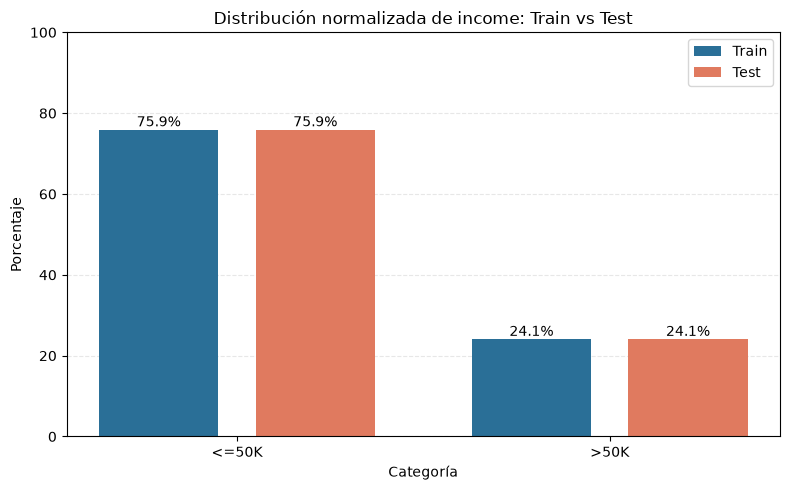

In [28]:
target_split_percentages = pd.DataFrame({
    "Train": train_df[TARGET].value_counts(normalize=True).mul(100),
    "Test": test_df[TARGET].value_counts(normalize=True).mul(100),
}).sort_index()

positions = range(len(target_split_percentages))
bar_width = 0.32
bar_offset = 0.21

fig, ax = plt.subplots(figsize=(8, 5))
train_bars = ax.bar(
    [position - bar_offset for position in positions],
    target_split_percentages["Train"],
    width=bar_width,
    color="#2a6f97",
    label="Train"
)
test_bars = ax.bar(
    [position + bar_offset for position in positions],
    target_split_percentages["Test"],
    width=bar_width,
    color="#e07a5f",
    label="Test"
)

ax.set_title(f"Distribución normalizada de {TARGET}: Train vs Test")
ax.set_xlabel("Categoría")
ax.set_ylabel("Porcentaje")
ax.set_xticks(range(len(target_split_percentages)), target_split_percentages.index)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

ax.bar_label(train_bars, fmt="%.1f%%")
ax.bar_label(test_bars, fmt="%.1f%%")
fig.tight_layout()
plt.show()